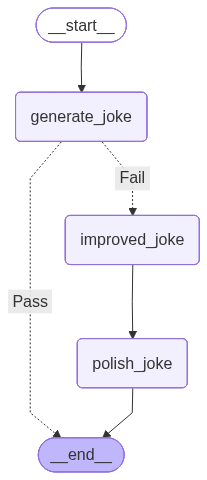

Initial joke:
Why did the cat sit on the keyboard?

To keep an eye on the mouse! 🐭🐱

--- --- ---

Final joke:
Why did the cat sit on the keyboard?

To keep an eye on the mouse! 🐭🐱


In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import config_data as config

"""
工具调用
结构化输出：千问、Deepseek不原生支持结构化输出，需要在prompt告诉AI输出样式
短期记忆
"""

load_dotenv()
llm = init_chat_model(
    model=config.chat_model_name,
    model_provider=config.chat_model_provider,
    base_url = os.getenv("DASHSCOPE_BASE_URL"),
    api_key = os.getenv("DASHSCOPE_API_KEY"),
    temperature=0.0,  # 🔥 必须 0
)

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimize web search.")
    justification: str = Field(None, description="Why this query is relevant to the user's request.")

# Augment the llm with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery, method="json_mode")
# output = structured_llm.invoke("身体不好，如何补钙? 请使用JSON格式输出")

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
# msg = llm_with_tools.invoke("What is 2 times 3?")

class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}

# punchline 结尾画龙点睛的妙语
def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

def improved_joke(state: State):
    """Second LLM call to improve joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay : {state['joke']}")
    return {"improved_joke": msg.content}

def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke : {state['improved_joke']}")
    return {"final_joke": msg.content}

# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improved_joke", improved_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke",
    check_punchline,
    {"Fail": "improved_joke", "Pass": END})
workflow.add_edge("improved_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Test
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])